In [1]:
import os
import re
from collections import Counter
import matplotlib.pyplot as plt

# === Configuration ===
folder_path = r"L:\43-RVZ\AIMicroscopy\Mitarbeiter\2_Data\1_NikonTi2\FK_P001_EX004_2025_03_04 60xWI 1.5x KEIO Plate61 Focusing Strategies\AF\TIF\results"  # <-- Replace with your folder path

# === Pattern to extract number ===
pattern = re.compile(r"sharpest_image_(\d+)\.tif$")

In [2]:
# === Extract numbers from file names ===
slice_numbers = []

for filename in os.listdir(folder_path):
    if filename.endswith(".tif"):
        match = pattern.search(filename)
        if match:
            slice_num = int(match.group(1))
            slice_numbers.append(slice_num)

# === Count occurrences ===
counts = Counter(slice_numbers)

In [3]:
# === Calculate statistics ===
total_n = sum(counts.values())
average = sum(k * v for k, v in counts.items()) / total_n
std_dev = (sum((k - average) ** 2 * v for k, v in counts.items()) / total_n) ** 0.5

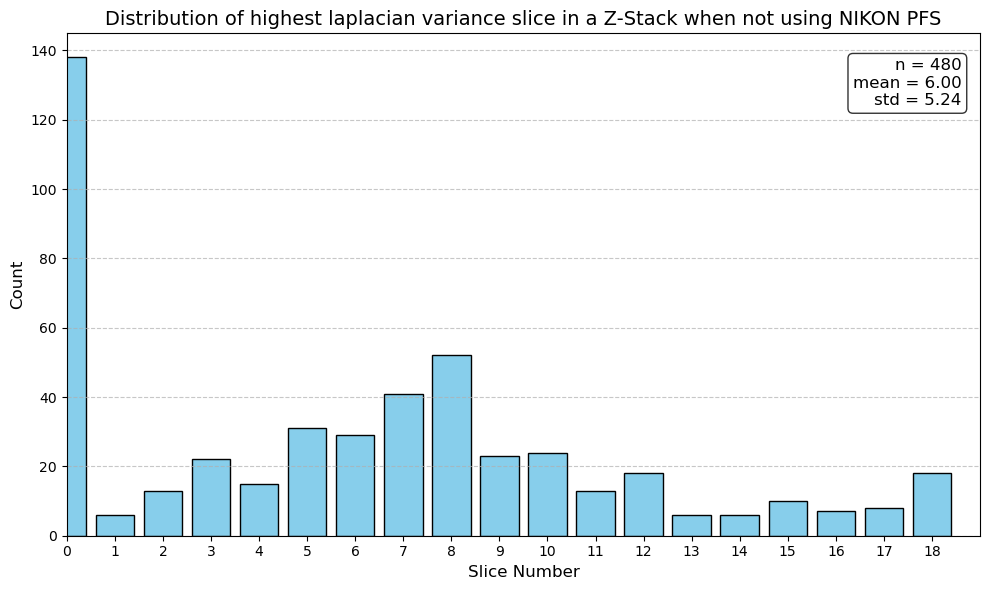

In [4]:
# === Plot histogram ===
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values(), color='skyblue', edgecolor='black')
plt.xlabel("Slice Number", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xlim(0, 19)
plt.title("Distribution of highest laplacian variance slice in a Z-Stack when not using NIKON PFS", fontsize=14)
plt.xticks(sorted(counts.keys()))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# === Add stats as text on plot ===
stats_text = f"n = {total_n}\nmean = {average:.2f}\nstd = {std_dev:.2f}"
plt.text(0.98, 0.95, stats_text,
         transform=plt.gca().transAxes,
         fontsize=12, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# === Save and show the plot ===
output_filename = "sharpest_slice_distribution_NIKON_PFS_ZStack.png"
plt.tight_layout()
plt.savefig(os.path.join(folder_path, output_filename), dpi=300)
plt.show()